# DATA SCIENCE

# 1. Load Data

### Import library

In [1]:
!pip install split-folders -q

In [2]:
import os
import glob
import shutil
import pandas as pd
import splitfolders
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import random
import matplotlib.pyplot as plt

### Inisialisasi sumber dataset (data didapat dari kaggle lalu disimpan di github)

In [3]:
# --- Konfigurasi Global ---
REPO_URL = 'https://github.com/happy-ending-forever/capstone-tomato-leafguard.git'
REPO_DIR = '/content/capstone-tomato-leafguard'
SEGMENTED_DIR = os.path.join(REPO_DIR, 'dataset', 'segmented')
OUTPUT_BASE = '/content/tomato_siap_training'
SEED = 28

In [4]:
# Melakukan git clone, jika folder sudah ada maka akan dilakukan git pull (Untuk kepentingan proses analisis)
if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
    print("Download selesai!")
else:
    %cd {REPO_DIR}
    !git pull
    %cd /content
    print("Repository sudah diperbarui ke versi terbaru.")

# Mengarahkan path langsung ke folder 'dataset' di dalam repository
print("\nIsi folder segmented (Daftar Kelas):")
try:
    folder_contents = os.listdir(SEGMENTED_DIR) # Menggunakan SEGMENTED_DIR
    print(folder_contents)
    print(f"Total kelas yang ditemukan: {len(folder_contents)} kelas")
    if len(folder_contents) == 0:
         print("Folder ditemukan, tapi isinya kosong.")
except FileNotFoundError:
    print(f"Error: Folder tidak ditemukan di {SEGMENTED_DIR}.")

/content/capstone-tomato-leafguard
Already up to date.
/content
Repository sudah diperbarui ke versi terbaru.

Isi folder segmented (Daftar Kelas):
['Tomato___Tomato_mosaic_virus', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Target_Spot', 'Tak_Terdefinisi', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Leaf_Mold', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Bacterial_spot']
Total kelas yang ditemukan: 11 kelas


**github sebagai data dictionary yang menyimpan hasil scrapping yang dilakukan pada notebook scrapping_tomato_leaf.ipynb**

# 2. EDA

### Melihat distribusi data tiap jenis penyakit

In [5]:
# Tampilan Dataset (frekuensi gambar berdasarkan penyakit)
data_info = []

if os.path.exists(SEGMENTED_DIR):
    for folder in sorted(os.listdir(SEGMENTED_DIR)):
        folder_path = os.path.join(SEGMENTED_DIR, folder)

        if os.path.isdir(folder_path) and not folder.startswith('.'):
            jumlah = len(os.listdir(folder_path))
            data_info.append({'Kategori Penyakit': folder, 'Jumlah Gambar': jumlah})

    df_info = pd.DataFrame(data_info)

    if not df_info.empty:
        total_gambar = df_info['Jumlah Gambar'].sum()
        print(f"Total keseluruhan gambar asli: {total_gambar}")
        print(f"Total jenis kategori: {len(df_info)}")
        print("-" * 35)
        print(df_info.to_string(index=False))
    else:
        print("Tidak ada folder kategori yang ditemukan di dalam SEGMENTED_DIR.")

Total keseluruhan gambar asli: 19160
Total jenis kategori: 11
-----------------------------------
                            Kategori Penyakit  Jumlah Gambar
                              Tak_Terdefinisi           1000
                      Tomato___Bacterial_spot           2127
                        Tomato___Early_blight           1000
                         Tomato___Late_blight           1909
                           Tomato___Leaf_Mold            952
                  Tomato___Septoria_leaf_spot           1771
Tomato___Spider_mites Two-spotted_spider_mite           1676
                         Tomato___Target_Spot           1404
       Tomato___Tomato_Yellow_Leaf_Curl_Virus           5357
                 Tomato___Tomato_mosaic_virus            373
                             Tomato___healthy           1591


**karena jumlah data tidak seimbang tiap kategori, maka akan dilakukan proses augmentasi pada data training agar semua kategori seimbang dan tidak membuat model menjadi bias**

# 3. Split Data

### 80 Training : 20 Testing

In [6]:
# Hapus folder output jika sebelumnya sudah ada
if os.path.exists(OUTPUT_BASE):
    shutil.rmtree(OUTPUT_BASE)

# Memecah data dari SEGMENTED_DIR ke OUTPUT_BASE
splitfolders.ratio(SEGMENTED_DIR, output=OUTPUT_BASE, seed=SEED, ratio=(.8, .2), move=False)

TRAIN_DIR = os.path.join(OUTPUT_BASE, 'train')
VAL_DIR = os.path.join(OUTPUT_BASE, 'val')

print(f"Data berhasil dipisah dan diamankan ke: {OUTPUT_BASE}")

Copying files: 19160 files [00:12, 1525.33 files/s]

Data berhasil dipisah dan diamankan ke: /content/tomato_siap_training


# 4. Feature Engineering (Augmentasi Gambar)

### Bertujuan untuk menyeimbangkan jumlah data tiap kategori penyakit.

In [7]:
# Augmentasi gambar (rotasi, flip, zoom, dll)
datagen = ImageDataGenerator(
    rotation_range=35,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.6, 1.4],
    channel_shift_range=50.0,
    fill_mode='nearest'
)

TARGET_COUNT = 1000 # Target hasil augmentasi agar frekuensi tiap penyakit seimbang sebanyak 1000

for kategori in os.listdir(TRAIN_DIR):
    kategori_path = os.path.join(TRAIN_DIR, kategori)
    if not os.path.isdir(kategori_path):
        continue

    gambar_saat_ini = glob.glob(os.path.join(kategori_path, '*.*'))
    jumlah_awal = len(gambar_saat_ini)

    print(f"\n[Proses] Kategori: {kategori} | Jumlah awal: {jumlah_awal}")

    if jumlah_awal == 0:
        continue

    # Undersampling jika data kelebihan
    if jumlah_awal > TARGET_COUNT:
        kelebihan = jumlah_awal - TARGET_COUNT
        print(f"  -> Mengurangi {kelebihan} gambar acak...")

        random.shuffle(gambar_saat_ini)
        for i in range(kelebihan):
            try:
                os.remove(gambar_saat_ini[i])
            except Exception:
                pass

    # Oversampling jika data kurang
    elif jumlah_awal < TARGET_COUNT:
        kekurangan = TARGET_COUNT - jumlah_awal
        print(f"  -> Menambah {kekurangan} gambar lewat augmentasi...")

        gambar_basis = glob.glob(os.path.join(kategori_path, '*.*'))
        jumlah_dibuat = 0

        while jumlah_dibuat < kekurangan:
            img_path = random.choice(gambar_basis)
            try:
                img = load_img(img_path)
                x = img_to_array(img)
                x = x.reshape((1,) + x.shape)

                for batch in datagen.flow(x, batch_size=1, save_to_dir=kategori_path, save_prefix='aug_bal', save_format='jpg'):
                    jumlah_dibuat += 1
                    break
            except Exception:
                continue

    else:
        print("  -> Data sudah pas 1000 gambar.")

    total_akhir = len(glob.glob(os.path.join(kategori_path, '*.*')))
    print(f"  -> Hasil Akhir Kategori {kategori}: {total_akhir} gambar.")


[Proses] Kategori: Tomato___Tomato_mosaic_virus | Jumlah awal: 298
  -> Menambah 702 gambar lewat augmentasi...
  -> Hasil Akhir Kategori Tomato___Tomato_mosaic_virus: 981 gambar.

[Proses] Kategori: Tomato___Spider_mites Two-spotted_spider_mite | Jumlah awal: 1340
  -> Mengurangi 340 gambar acak...
  -> Hasil Akhir Kategori Tomato___Spider_mites Two-spotted_spider_mite: 1000 gambar.

[Proses] Kategori: Tomato___Early_blight | Jumlah awal: 800
  -> Menambah 200 gambar lewat augmentasi...
  -> Hasil Akhir Kategori Tomato___Early_blight: 993 gambar.

[Proses] Kategori: Tomato___Septoria_leaf_spot | Jumlah awal: 1416
  -> Mengurangi 416 gambar acak...
  -> Hasil Akhir Kategori Tomato___Septoria_leaf_spot: 1000 gambar.

[Proses] Kategori: Tomato___Target_Spot | Jumlah awal: 1123
  -> Mengurangi 123 gambar acak...
  -> Hasil Akhir Kategori Tomato___Target_Spot: 1000 gambar.

[Proses] Kategori: Tak_Terdefinisi | Jumlah awal: 800
  -> Menambah 200 gambar lewat augmentasi...
  -> Hasil Akhir 

Augmentasi dilakukan dengan cara gambar diputar, dibalik, di zoom, dll. Selain untuk menyeimbangkan jumlah kategori, Augmentasi juga digunakan untuk menambah keragaman data

### Contoh gambar hasil augmentasi.

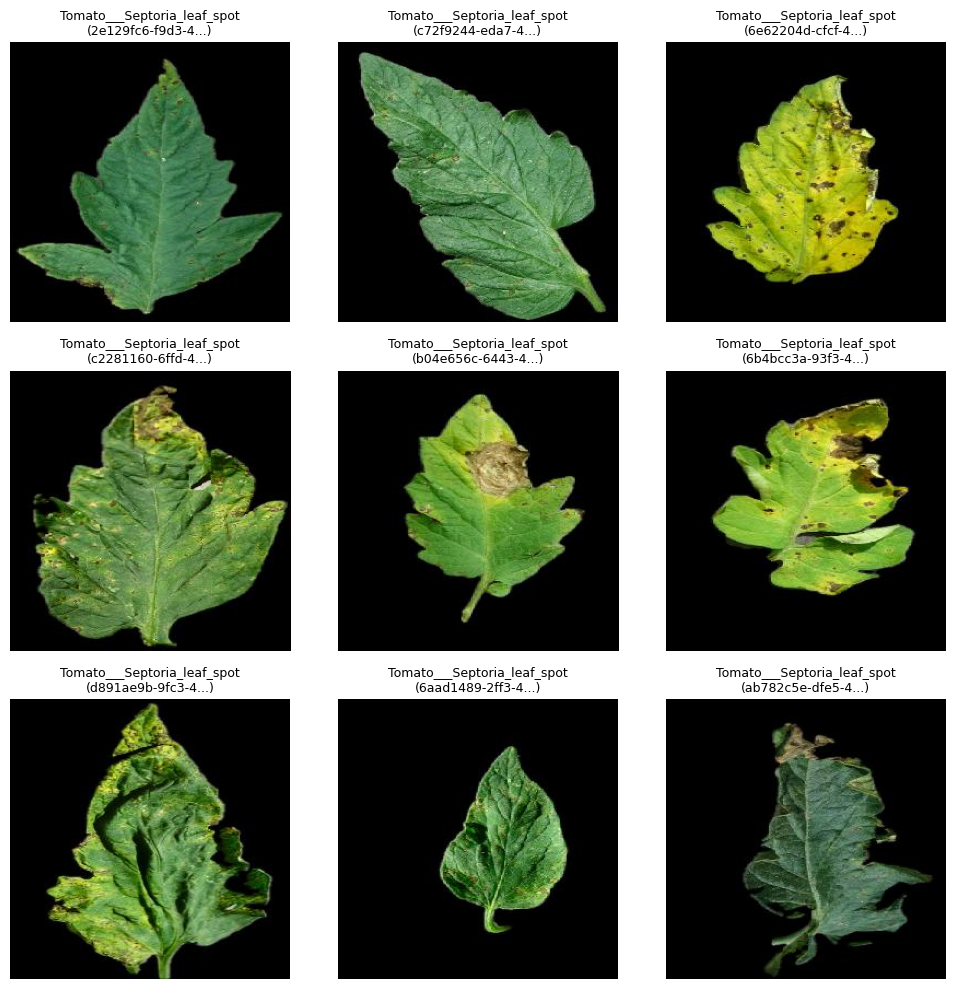

In [8]:
# Preview gambar training
kategori_penyakit = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
kategori_acak = random.choice(kategori_penyakit)
kategori_path = os.path.join(TRAIN_DIR, kategori_acak)

# Mengambil semua file gambar
semua_gambar = [f for f in os.listdir(kategori_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if len(semua_gambar) >= 9:
    file_terpilih = random.sample(semua_gambar, 9)

    plt.figure(figsize=(10, 10))
    for i, file_name in enumerate(file_terpilih):
        img_path = os.path.join(kategori_path, file_name)
        img = load_img(img_path)

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"{kategori_acak}\n({file_name[:15]}...)", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"Gambar di folder {kategori_acak} kurang dari 9 untuk ditampilkan.")

# AI ENGINEER

# 1. Import Library

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import gc
import numpy as np
from google.colab import files

# 2. Load Data

In [10]:
train_dir = '/content/tomato_siap_training/train'
val_dir = '/content/tomato_siap_training/val'

# Mengurangi resolusi ke 128 dan batch size ke 16 untuk menghemat RAM
img_height, img_width, batch_size = 128, 128, 16

print("Membaca data gambar...")
train_data = tf.keras.utils.image_dataset_from_directory(
  train_dir, seed=123, image_size=(img_height, img_width), batch_size=batch_size)
val_data = tf.keras.utils.image_dataset_from_directory(
  val_dir, seed=123, image_size=(img_height, img_width), batch_size=batch_size)

AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.shuffle(500).prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)

Membaca data gambar...
Found 10973 files belonging to 11 classes.
Found 3837 files belonging to 11 classes.


# 3. Membangun Arsitektur dan Training Model (CNN)

In [11]:
tf.keras.backend.clear_session()
gc.collect()

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(11, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Mulai training Model (Optimasi RAM Maksimal)...")
history = model.fit(train_data, validation_data=val_data, epochs=30, callbacks=[early_stop])

Mulai training Model (Optimasi RAM Maksimal)...
Epoch 1/30
686/686 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.3118 - loss: 1.8705 - val_accuracy: 0.3839 - val_loss: 1.6676
Epoch 2/30
686/686 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4496 - loss: 1.5188 - val_accuracy: 0.4259 - val_loss: 1.5721
Epoch 3/30
686/686 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.5093 - loss: 1.3557 - val_accuracy: 0.5679 - val_loss: 1.2969
Epoch 4/30
686/686 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5524 - loss: 1.2454 - val_accuracy: 0.4662 - val_loss: 1.4068
Epoch 5/30
686/686 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5920 - loss: 1.1474 - val_accuracy: 0.6609 - val_loss: 1.0628
Epoch 6/30
686/686 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6217 - loss: 1.0693 - val_accuracy: 0.6437 - val_loss: 1.0564
Epoch 7/30
686/686 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6430 - loss: 1.0090 - val_accuracy: 0.6771 - val_loss: 0.9925
Epoch 8/30
686/686 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/

# 4. Grafik Peforma Model

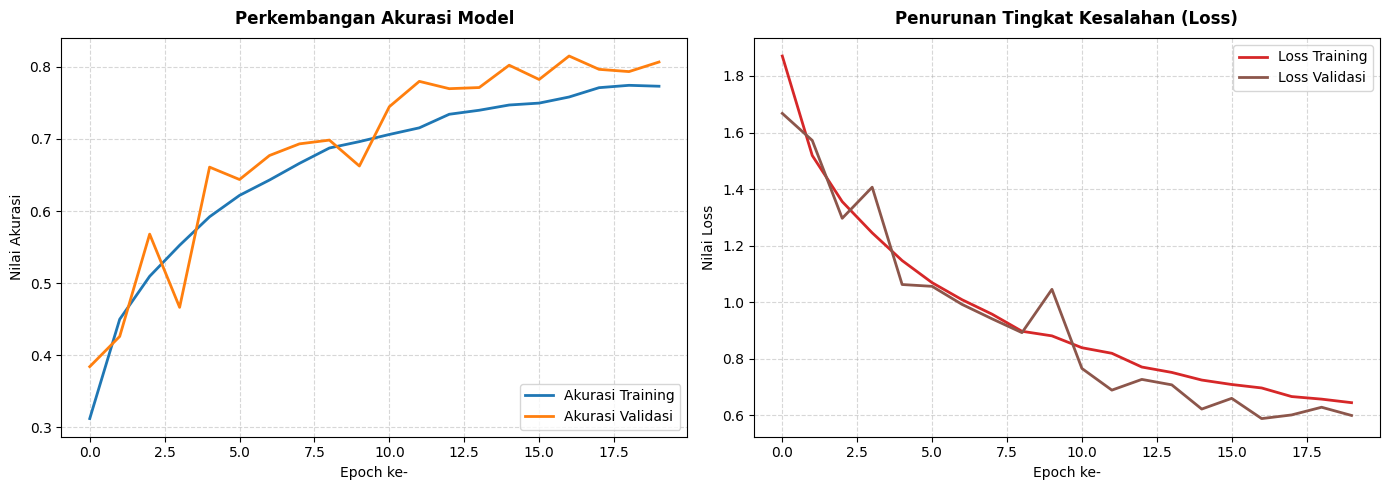

In [12]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# GRAFIK 1: AKURASI
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Training', color='#1f77b4', linewidth=2)
plt.plot(epochs_range, val_acc, label='Akurasi Validasi', color='#ff7f0e', linewidth=2)
plt.title('Perkembangan Akurasi Model', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epoch ke-')
plt.ylabel('Nilai Akurasi')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)

# GRAFIK 2: LOSS
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Training', color='#d62728', linewidth=2)
plt.plot(epochs_range, val_loss, label='Loss Validasi', color='#8c564b', linewidth=2)
plt.title('Penurunan Tingkat Kesalahan (Loss)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epoch ke-')
plt.ylabel('Nilai Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 5. Kode Inference

Saving 000146ff-92a4-4db6-90ad-8fce2ae4fddd___GH_HL Leaf 259.1.JPG to 000146ff-92a4-4db6-90ad-8fce2ae4fddd___GH_HL Leaf 259.1 (16).JPG

Memproses gambar: 000146ff-92a4-4db6-90ad-8fce2ae4fddd___GH_HL Leaf 259.1 (16).JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step


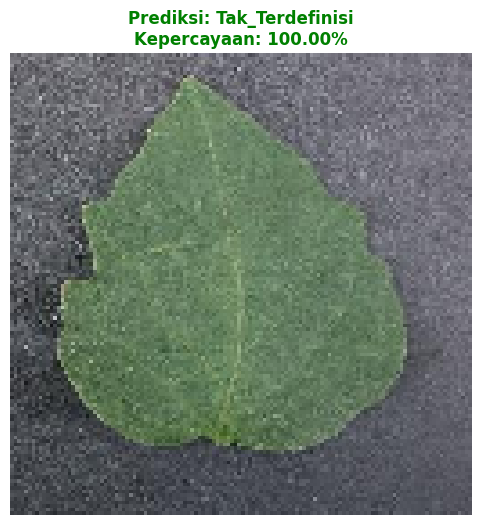

In [15]:
file_model = '/content/model_tomato_leaf_guardai.keras'
model = load_model(file_model)

daftar_kelas = [
    'Tak_Terdefinisi',
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

def prediksi_penyakit_tomat(img_path):
    print(f"\nMemproses gambar: {img_path}")

    img = load_img(img_path, target_size=(128, 128))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    score = predictions[0]

    max_prob = np.max(score)
    predicted_class_index = np.argmax(score)

    nama_prediksi = daftar_kelas[predicted_class_index]

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')

    judul = f"Prediksi: {nama_prediksi}\nKepercayaan: {max_prob*100:.2f}%"
    plt.title(judul, color='green', fontweight='bold')

    plt.show()

uploaded = files.upload()

for fn in uploaded.keys():
    prediksi_penyakit_tomat(fn)

#### Gambar diatas adalah gambar daun yang sehat, tetapi model memprediksi sebagai kelas tidak terdefinisi. Baik role data science maupun AI engineer berasumsi bahwa terdapat masalah perbedaan dimensi, dimana model dilatih dengan gambar tanpa background (background hitam) sedangkan gambar yang diberikan memiliki background yang jelas berwarna, ditambah lagi untuk kategori data tak terdefinisi sendiri memang berdeda yakni berisi gambar random yang memiliki background jelas sehingga memperkuat asumsi. Untuk mengatasi masalah ini, akan ditambahkan fungsi penghapus background dari library rembg milik python. Rencananya fungsi ini akan digunakan di bagian backend, tapi untuk kebutuhan testing ETL dan hasil prediksi maka dibuat prototype pada **no 7**

# 6. Save Model

In [16]:
# menyimpan model
model.save('model_tomato_leaf_guardai.keras')
print("=> Model berhasil disimpan di Google Colab!")

=> Model berhasil disimpan di Google Colab!


# 7. TESTING PROTOTYPE

In [17]:
!pip install rembg -q
!pip install onnxruntime "rembg[gpu]" -q

**terdapat beberapa pesan error karena instalasi onnxruntime memerlukan numpy yang berbeda versi dengan milik google colab**

Saving 000146ff-92a4-4db6-90ad-8fce2ae4fddd___GH_HL Leaf 259.1.JPG to 000146ff-92a4-4db6-90ad-8fce2ae4fddd___GH_HL Leaf 259.1 (17).JPG

Memproses gambar: 000146ff-92a4-4db6-90ad-8fce2ae4fddd___GH_HL Leaf 259.1 (17).JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step


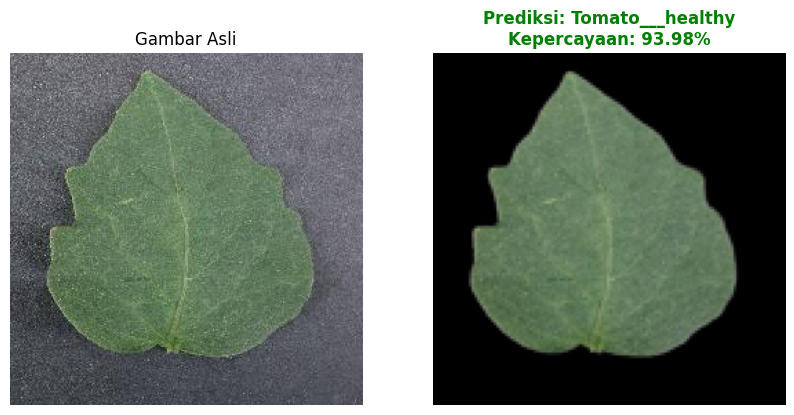

In [18]:
import numpy as np
from rembg import remove
from PIL import Image

# Sesuaikan nama file ini dengan nama file .keras milikmu di panel kiri Colab
file_model = '/content/model_tomato_leaf_guardai.keras'
model = load_model(file_model)

daftar_kelas = [
    'Tak_Terdefinisi',
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]


def prediksi_dengan_model_tersimpan(nama_file):
    print(f"\nMemproses gambar: {nama_file}")

    img_asli = Image.open(nama_file)

    # Hapus background
    img_tanpa_bg = remove(img_asli)

    # Ubah ke background hitam pekat (agar cocok dengan data segmented)
    background_hitam = Image.new("RGB", img_tanpa_bg.size, (0, 0, 0))
    background_hitam.paste(img_tanpa_bg, mask=img_tanpa_bg.split()[3])

    # Resize sesuai target_size modelmu 128
    img_resized = background_hitam.resize((128, 128))

    # Ubah ke array numpy
    img_array = image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)

    # PREDIKSI
    predictions = model.predict(img_array)
    score = predictions[0]

    max_prob = np.max(score)
    predicted_class_index = np.argmax(score)
    nama_prediksi = daftar_kelas[predicted_class_index]

    # TAMPILKAN HASIL
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(img_asli)
    ax[0].set_title("Gambar Asli")
    ax[0].axis('off')

    ax[1].imshow(img_resized)
    if max_prob < 0.40:
        judul = f"Tak Terdefinisi / Ragu-ragu\n(Tebakan: {nama_prediksi} - {max_prob*100:.2f}%)"
        ax[1].set_title(judul, color='red', fontweight='bold')
    else:
        judul = f"Prediksi: {nama_prediksi}\nKepercayaan: {max_prob*100:.2f}%"
        ax[1].set_title(judul, color='green', fontweight='bold')
    ax[1].axis('off')

    plt.show()

# Upload testing
uploaded = files.upload()

for fn in uploaded.keys():
    prediksi_dengan_model_tersimpan(fn)

**setelah proses ETL berupa upload file > hapus background > prediksi**

didapat hasil yang sesuai yakni prediksi daun sehat, dengan ini maka asumsi awal memang benar sehingga nantinya proses ini akan digunakan pada bagian backend untuk hasil yang maksimal